In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from expconfig import ExpConfig
from icprem import PREM_IC_RHO, PREM_IC_VP
from sampling.priors import CompoundPrior
from tti.traveltimes import TravelTimeCalculator

In [2]:
rng = np.random.default_rng(1234)
normalisation = -1 / (2 * PREM_IC_RHO * (PREM_IC_VP * 1e3) ** 2)

In [3]:
cfg = ExpConfig.load("../config.yaml")

prior = CompoundPrior.from_dict(cfg.priors.model_dump())
prior_samples = prior.sample(10_000, rng)

In [4]:
noise_levels: dict[str, float] = {
    "ab": 0.95,
    "bc": 0.63,
    "cd": 0.29,
    "df": 0.95,
}

DATA_FILE = Path().resolve().parent / "data" / "brett2024_ic_traveltimes.parquet"

df = pd.read_parquet(DATA_FILE)
ic_in = np.stack(df.in_location.values)
ic_out = np.stack(df.out_location.values)

In [ ]:
from icprem import PREM_IC_RHO, PREM_IC_VP
from tti.traveltimes.paths import calculate_path_direction_vector

region = cfg.geometry.to_composite_region()

normalisation = -1 / (2 * PREM_IC_RHO * (PREM_IC_VP * 1e3) ** 2)

path_directions = calculate_path_direction_vector(ic_in, ic_out)
total_distances = region.ray_distances(ic_in, path_directions)

# Not sure why some rays have zero total distance.  Discard for now
valid_rays = total_distances > 0
ic_in = ic_in[valid_rays]
ic_out = ic_out[valid_rays]
path_directions = path_directions[valid_rays]
segment_distances = region.ray_distances_per_region(ic_in, path_directions)
weights = segment_distances / total_distances[valid_rays, None]

dt_over_t = (df.delta_t / df.inner_core_travel_time).values[valid_rays]
#  The noise levels for each reference phase are given in seconds, so we need to convert them to fractional traveltime perturbations by dividing by the inner core travel time.
# In principle this gives a different sigma for each observation.
sigma = (df["reference_phase"].map(noise_levels) / df["inner_core_travel_time"]).values[
    valid_rays
]

In [6]:
ttc = TravelTimeCalculator(
    ic_in,
    ic_out,
    normalisation=normalisation,
    weights=weights.T,
    nested=True,
    shear=True,
    N=False,
)
prior_predictive = ttc(prior_samples)
prior_predictive += rng.normal(
    loc=0.0,
    scale=sigma,
    size=prior_predictive.shape,
)

Text(0.5, 0, 'Fractional Traveltime perturbation dt / t')

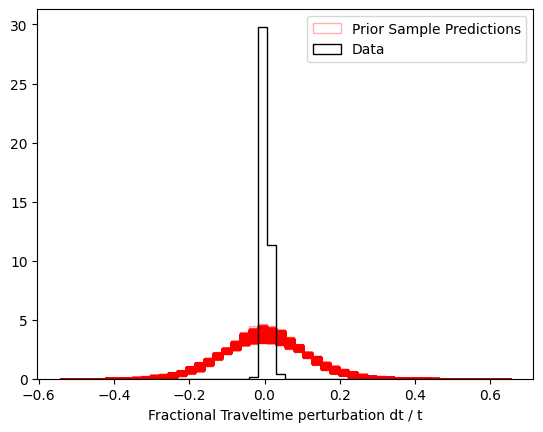

In [7]:
all_dists = np.vstack([prior_predictive, dt_over_t[None, :]])
hist_range = (all_dists.min(), all_dists.max())
common_kwargs = {
    "bins": 50,
    "histtype": "step",
    "range": hist_range,
    "density": True,
}
fig, ax = plt.subplots(
    1,
    1,
)
ax.hist(
    prior_predictive,
    **common_kwargs,
    color=np.full(prior_predictive.shape[1], "r"),
    alpha=0.3,
    label="Prior Sample Predictions",
)
ax.hist(
    dt_over_t,
    **common_kwargs,
    color="k",
    label="Data",
)
ax.legend()
ax.set_xlabel("Fractional Traveltime perturbation dt / t")